# 03 — Trénink UNETR

UNETR nahrazuje konvoluční enkodér **Vision Transformerem**. Trénuje se za
naprosto stejných podmínek jako U-Net — stejná data, stejný split, stejné
augmentace, stejný seed, stejná trénovací smyčka. Liší se jen architektura
(a learning rate, viz níže).

Teorie: [`devnotes/teorie/02_vision_transformer_a_unetr.md`](../devnotes/teorie/02_vision_transformer_a_unetr.md)

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() if Path.cwd().name == "notebooks" else Path.cwd() / "notebooks"))
from _common import *
import cv2, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
print("repo:", REPO_ROOT)

repo: C:\GitHub\USU-zapocet


## 1. Porovnání konfigurací

Ukážeme si rozdíly proti U-Netu explicitně — u srovnávací studie je zásadní umět
doložit, že se neliší nic jiného než to, co se lišit má.

In [2]:
import yaml
u = yaml.safe_load((REPO_ROOT / "training/configs/unet.yaml").read_text(encoding="utf-8"))
t = yaml.safe_load((REPO_ROOT / "training/configs/unetr.yaml").read_text(encoding="utf-8"))

def flat(d, pre=""):
    out = {}
    for k, v in d.items():
        out.update(flat(v, f"{pre}{k}.")) if isinstance(v, dict) else out.update({f"{pre}{k}": v})
    return out

fu, ft = flat(u), flat(t)
rows = [{"parametr": k, "U-Net": fu.get(k), "UNETR": ft.get(k)}
        for k in sorted(set(fu) | set(ft)) if fu.get(k) != ft.get(k)]
print("ROZDÍLY:"); display(pd.DataFrame(rows))
print(f"\nshodných parametrů: {sum(1 for k in fu if fu.get(k) == ft.get(k))}")

ROZDÍLY:


,parametr,U-Net,UNETR
0,model.vit_size,None,tiny
1,optimizer.lr,0.001,0.0003
2,run.name,unet-atlas-v1,unetr-atlas-v1
3,scheduler.t0,5,15
4,scheduler.warmup_epochs,None,2



shodných parametrů: 27


### Proč má UNETR jiný learning rate

S hodnotou `1e-2` UNETR **diverguje na `nan` hned po první epoše**. `1e-4` je
hodnota z originální publikace UNETR (Hatamizadeh et al., 2021) a je to běžný
řád pro Vision Transformery.

Rozdílný learning rate mezi architekturami je legitimní — je to standardní
per-architekturu laděný hyperparametr. Použít pro transformer hodnotu vyladěnou
pro CNN by naopak bylo metodicky horší: srovnávali bychom zdivergovaný model.

## 2. Architektura a její cena

UNETR má i po zmenšení víc parametrů než U-Net. Velikost použitého Vision
Transformeru se bere **z configu**, ne z výchozí hodnoty MONAI — proč, to
vysvětluje kapitola 3.

In [3]:
import torch
from training.common.models import build_unet, build_unetr, VIT_SIZES

vit_size = t.get("model", {}).get("vit_size", "base")
unet, unetr = build_unet(), build_unetr(patch_size=256, vit_size=vit_size)
pu = sum(p.numel() for p in unet.parameters())
pt = sum(p.numel() for p in unetr.parameters())
print(f"U-Net                  {pu/1e6:7.2f} M parametrů")
print(f"UNETR (ViT-{vit_size:<5s})      {pt/1e6:7.2f} M parametrů   ({pt/pu:.0f}x více)")

print("\nvšechny dostupné velikosti ViT (hidden, mlp, heads):")
for name, cfg in VIT_SIZES.items():
    mark = "  <- použitá" if name == vit_size else ""
    print(f"  {name:6s} {cfg}{mark}")

x = torch.randn(1, 3, 256, 256)
print("\nvýstup UNETR:", tuple(unetr(x).shape))

U-Net                     1.63 M parametrů
UNETR (ViT-tiny )         8.39 M parametrů   (5x více)

všechny dostupné velikosti ViT (hidden, mlp, heads):
  base   (768, 3072, 12)
  small  (384, 1536, 6)
  tiny   (192, 768, 3)  <- použitá



výstup UNETR: (1, 7, 256, 256)


## 3. Proč zmenšený transformer — výsledky ladění

Ve zkušebních bězích se ukázalo, že UNETR s výchozím nastavením MONAI
(ViT-Base, 116 M parametrů) se na našich datech prakticky **nerozjede**.
Následovaly čtyři iterace ladění, všechny za identických podmínek
(400 snímků, 10 epoch) — podrobnosti v
[`devnotes/STAV_PROJEKTU.md`](../devnotes/STAV_PROJEKTU.md) §8.10.

| varianta | parametrů | val Dice | vs výchozí |
|---|---:|---:|---:|
| ViT-Base, `lr 1e-4`, `T_0 5`, náhodné výřezy | 116 M | 0,078 | — |
| ViT-Base, `lr 3e-4`, `T_0 15`, náhodné výřezy | 116 M | ~0,015 | **horší** |
| ViT-Base + cílené výřezy + rozjezd LR | 116 M | 0,182 | 2,3× |
| **ViT-Tiny + cílené výřezy + rozjezd LR** | **8,4 M** | **0,400** | **5,1×** |

Nejcennější poučení: **první hypotéza byla mylná.** Sázelo se na learning rate
a scheduler, jenže samotné zvýšení LR výsledek naopak *zhoršilo*. Skutečné
příčiny byly dvě jiné:

1. **Vzorkování výřezů.** Obratle zabírají jen ~3 % plochy snímku, takže 15,6 %
   rovnoměrně náhodných výřezů neobsahovalo vůbec žádné popředí. Model dostával
   převážně signál „všechno je pozadí" a triviální řešení je pro něj silné
   lokální minimum. Cílené vzorkování (80 % výřezů vystředěných na obratel)
   snížilo podíl prázdných na 4,4 %.
2. **Kapacita vzhledem k objemu dat.** 116 M parametrů na 2978 snímcích je
   72násobek U-Netu. To nebyl handicap *ve prospěch* UNETR, ale proti němu.

Obojí je nasazené i u U-Netu tam, kde jde o datovou pipeline — cílené
vzorkování musí být u obou modelů stejné, jinak by se nesrovnávaly architektury,
ale předzpracování. Ověřeno, že U-Netu taky pomohlo (0,883 → 0,897).

### Proč zrovna 256 px

Self-attention porovnává každý token s každým, takže její cena roste
**kvadraticky s počtem tokenů**. Při dělení obrazu na dlaždice 16×16 px:

| velikost výřezu | tokenů | dvojic (∝ cena attention) |
|---|---|---|
| 512×512 | 32×32 = 1024 | ~1 050 000 |
| 256×256 | 16×16 = 256 | ~65 500 |

Naměřená propustnost to potvrzuje — tabulka je v
[`devnotes/STAV_PROJEKTU.md`](../devnotes/STAV_PROJEKTU.md) §4.3. Přechod na
256 px dal u UNETR **pětinásobnou propustnost**, mixed precision další zhruba
dvojnásobek.

U-Net je proti tomu tak levný, že by mu 512 px nevadilo — ale musí mít **stejné
podmínky** jako UNETR, jinak by srovnání nic neznamenalo.

## 4. Test průchodnosti

⚠️ Stejně jako u U-Netu běží pod vlastním jménem (`--run-name smoke-unetr`),
aby nepřepsal checkpointy ostrého běhu.

In [4]:
run_script("training/train_unetr.py", "--run-name", "smoke-unetr",
           "--max-epochs", "2", "--limit-train", "16", "--limit-val", "2", "--no-resume")

$ py -3 -u training/train_unetr.py --run-name smoke-unetr --max-epochs 2 --limit-train 16 --limit-val 2 --no-resume



[model] UNETR ViT-tiny: 8.4 M parametru


[train_unetr] run=smoke-unetr train_batches/epoch=16 val_images=2


[hw] GPU: NVIDIA GeForce RTX 3060 Laptop GPU | VRAM 6.44 GB | torch 2.11.0+cu128 | AMP zapnuto


[smoke-unetr] epoch 0: loss=2.6535 train_dice=0.0369 val_dice=- lr=1.50e-04 (1.1min)


[smoke-unetr] epoch 1: loss=2.3775 train_dice=0.0355 val_dice=0.0066 lr=3.00e-04 (0.0min+0.3min val)


[train_unetr] hotovo: {'best_val_dice': 0.0066324081271886826, 'last_epoch': 1, 'stopped_reason': 'max_epochs_reached'}



[navratovy kod: 0]


0

## 5. Ostrý trénink

Naměřeno na plných datech: **7,0 min na epochu** + 1,8 min na plnou
sliding-window validaci (běží každou 5. epochu). 60 epoch tedy vyjde
zhruba na **7,4 h**.

In [5]:
# ODKOMENTUJ pro ostrý trénink:
# run_script("training/train_unetr.py", "--max-minutes", "360")

print("Spouštět raději z terminálu:")
print("  py -3 -u training/train_unetr.py --max-minutes 360")

Spouštět raději z terminálu:
  py -3 -u training/train_unetr.py --max-minutes 360


## 6. Srovnání průběhu obou modelů

Křivky se načítají z TensorBoard logů ostrého běhu (`unet-atlas-v1`,
`unetr-atlas-v1`), ne z testu průchodnosti výše.

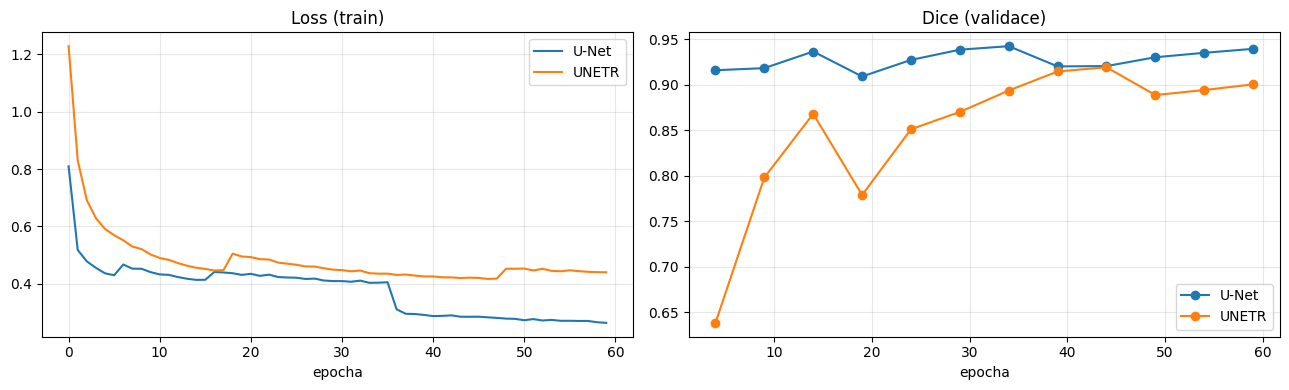

In [6]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def load_curves(run_name):
    run_dir = OUTPUTS_DIR / "runs" / run_name
    if not run_dir.exists(): return {}
    acc = EventAccumulator(str(run_dir)); acc.Reload()
    return {tag: ([e.step for e in acc.Scalars(tag)], [e.value for e in acc.Scalars(tag)])
            for tag in acc.Tags()["scalars"]}

cu, ct = load_curves("unet-atlas-v1"), load_curves("unetr-atlas-v1")

if cu or ct:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    for c, name in ((cu, "U-Net"), (ct, "UNETR")):
        if "Loss/train" in c: ax[0].plot(*c["Loss/train"], label=name)
        if "Dice/val" in c:   ax[1].plot(*c["Dice/val"], "o-", label=name)
    ax[0].set_title("Loss (train)"); ax[1].set_title("Dice (validace)")
    for a in ax: a.set_xlabel("epocha"); a.legend(); a.grid(alpha=.3)
    plt.tight_layout(); plt.show()
else:
    print("Zatím nejsou logy — nejdřív trénink.")

➡️ Dál: [`04_totalsegmentator.ipynb`](04_totalsegmentator.ipynb)